# Multi-view and Stereo Reconstruction

The implementation follows the reference code from `Programming Computer Vision in Python - Solem`:

- Chapter 5: regarding epipolar geometry, camera matrices, triangulation, resection, multi-view reconstruction, and stereo disparity.
- Section 1.5: ROF image de-noising.

## Method

1. Load the three `.jpg` images.
2. Find SIFT features and match image pairs.
3. Use RANSAC to keep matches that agree with one fundamental matrix.
4. Use the first two images to get camera matrices and triangulated 3D points.
5. Match image 2 to existing points and estimate its camera matrix by resection.
6. Rectify the first two images and compute SSD disparity maps with filtered patch sums.
7. Smooth the disparity maps with ROF de-noising and compare patch sizes.

The 3D reconstruction is relative, not metric. As we lack a camera calibration matrix, an approximate calibration is used only to make a useful reconstruction and plot camera positions.

## Theory

Per Solem Chapter 5, which uses the epipolar constraint

$$x_2^T F x_1 = 0$$

to describe the relation between corresponding points in two views. The normalized eight-point algorithm estimates `F` by solving a linear system with SVD and then forcing rank 2.

Triangulation computes a 3D point from its two image projections and two camera matrices. Resection is the reverse problem: when 3D points are known, their 2D projections are used to estimate another camera matrix.

For stereo, Solem's NCC example computes patch scores with filtering. Here SSD is used instead:

$$f(I_1, I_2) = (I_1 - I_2)^2$$

ROF smoothing from Section 1.5 is used because raw disparity maps have speckle (high frequency, non-Gaussian) noise, while depth should usually be piecewise smooth with clear edges.

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

# Global parameters

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['image.cmap'] = 'gray'

MAX_FEATURES = 2500
RATIO_TEST = 0.75
RANSAC_THRESHOLD_PX = 1.0
PATCH_SIZES = [7, 11, 19]
MAX_DISPARITY = 64
RANDOM_SEED = 7

## 1. Load the image set

I have used 3 images of the Oxford University Library from the [Oxford Multi-view Image Dataset](https://www.robots.ox.ac.uk/)

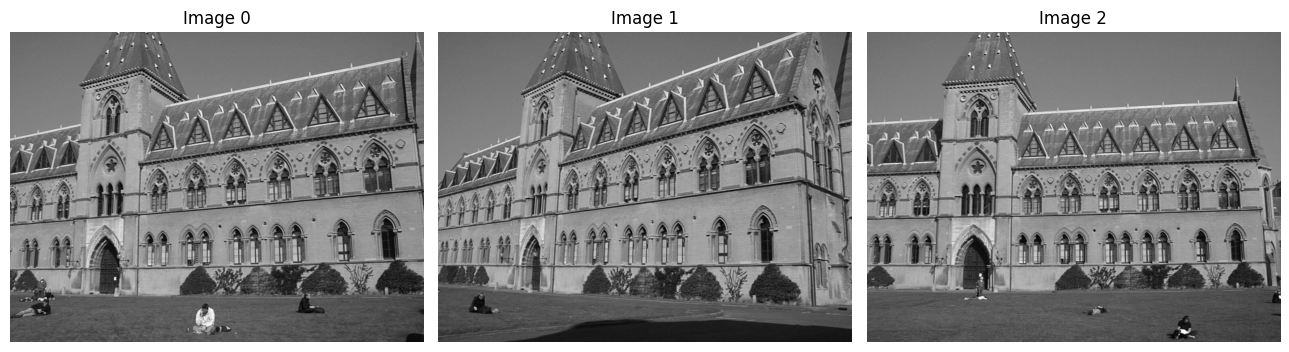

In [15]:
imgs = {
    0: cv2.imread(str(r'figures\001.jpg'), cv2.IMREAD_GRAYSCALE),
    1: cv2.imread(str(r'figures\002.jpg'), cv2.IMREAD_GRAYSCALE),
    2: cv2.imread(str(r'figures\003.jpg'), cv2.IMREAD_GRAYSCALE),
}

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for i, ax in enumerate(axes):
    ax.imshow(imgs[i], cmap='gray')
    ax.set_title(f'Image {i}')
    ax.axis('off')
plt.tight_layout()
plt.show()

## 2. Extract and match SIFT features

SIFT is used because the same scene point can appear at different scales and viewpoints. Lowe's ratio test removes ambiguous descriptor matches before geometry is estimated.

In [ ]:
@dataclass
class Features:
    keypoints: list[cv2.KeyPoint]
    descriptors: np.ndarray
    points: np.ndarray


def sift_extract(img: np.ndarray, max_features: int = MAX_FEATURES) -> Features:
    if img is None or img.size == 0:
        raise ValueError('SIFT input image is empty.')
    if img.dtype != np.uint8:
        img = np.clip(img, 0, 255).astype(np.uint8)

    sift = cv2.SIFT_create(nfeatures=max_features)
    keypoints, descriptors = sift.detectAndCompute(img, None)
    if descriptors is None or len(keypoints) == 0:
        raise ValueError('No SIFT descriptors found.')
    points = np.float32([kp.pt for kp in keypoints])
    return Features(keypoints, descriptors, points)

# Lowe's ratio test for feature matching
def match_features(desc_a: np.ndarray, desc_b: np.ndarray, ratio: float = RATIO_TEST) -> list[cv2.DMatch]:
    matcher = cv2.BFMatcher(cv2.NORM_L2)
    knn = matcher.knnMatch(desc_a, desc_b, k=2)
    good = []
    for pair in knn:
        if len(pair) < 2:
            continue
        m, n = pair
        if m.distance < ratio * n.distance:
            good.append(m)
    return good


def match_points(matches: list[cv2.DMatch], feat_a: Features, feat_b: Features) -> tuple[np.ndarray, np.ndarray]:
    pts_a = np.float32([feat_a.keypoints[m.queryIdx].pt for m in matches])
    pts_b = np.float32([feat_b.keypoints[m.trainIdx].pt for m in matches])
    return pts_a, pts_b


features = {i: sift_extract(img) for i, img in imgs.items()}
matches_01 = match_features(features[0].descriptors, features[1].descriptors)
matches_02 = match_features(features[0].descriptors, features[2].descriptors)

print('feature counts:', {i: len(f.keypoints) for i, f in features.items()})
print('raw matches image 0-1:', len(matches_01))
print('raw matches image 0-2:', len(matches_02))

feature counts: {0: 2501, 1: 2500, 2: 2500}
raw matches image 0-1: 434
raw matches image 0-2: 606


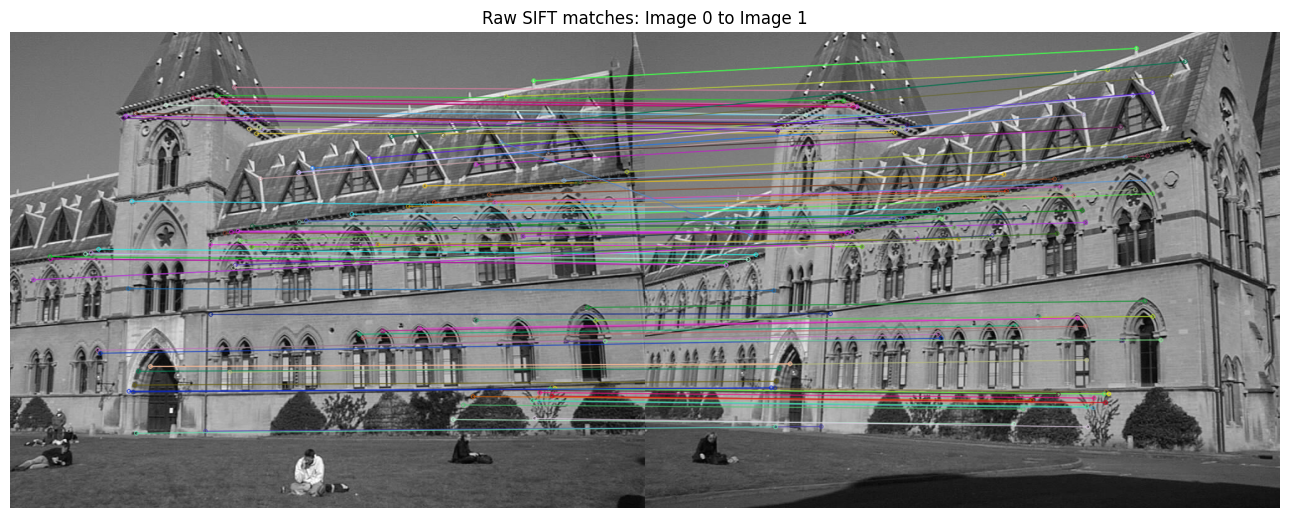

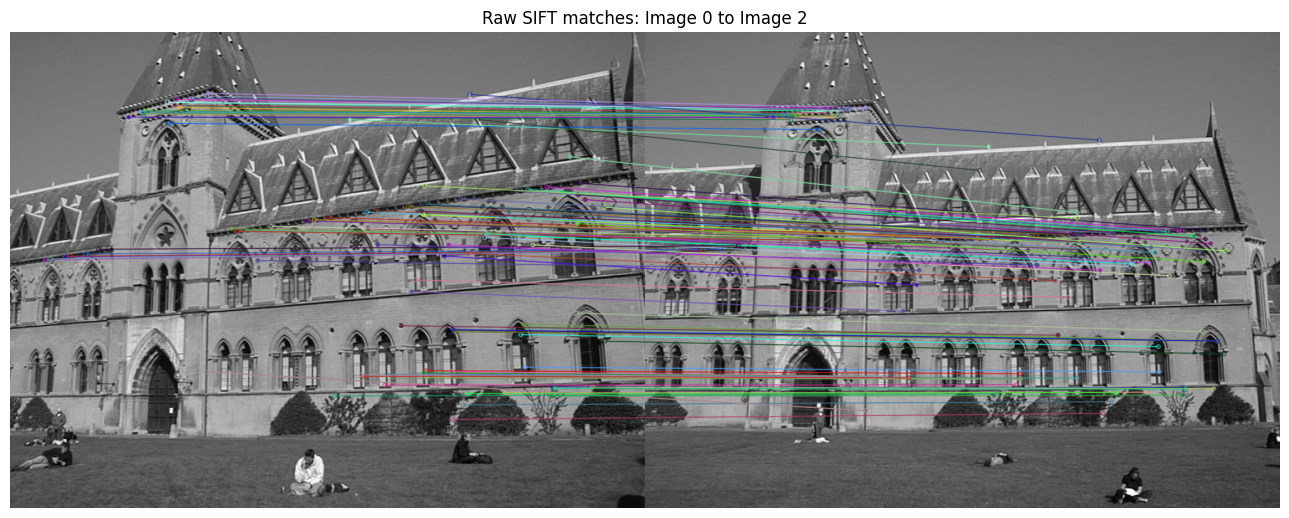

In [17]:
def show_matches(img_a, img_b, feat_a, feat_b, matches, title, max_matches=120):
    shown = sorted(matches, key=lambda m: m.distance)[:max_matches]
    drawn = cv2.drawMatches(
        img_a, feat_a.keypoints, img_b, feat_b.keypoints, shown, None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS,
    )
    plt.figure(figsize=(13, 6))
    plt.imshow(drawn, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.tight_layout()
    plt.show()


show_matches(imgs[0], imgs[1], features[0], features[1], matches_01, 'Raw SIFT matches: Image 0 to Image 1')
show_matches(imgs[0], imgs[2], features[0], features[2], matches_02, 'Raw SIFT matches: Image 0 to Image 2')

## 3. Geometry helper functions

These functions mirror the formulas used in Solem Chapter 5:

- normalized eight-point estimation of `F`,
- SVD triangulation,
- DLT camera resection from 2D-3D correspondences,
- camera center extraction from a projection matrix.

In [18]:
def homogeneous(points: np.ndarray) -> np.ndarray:
    return np.vstack([points.T, np.ones(points.shape[0])])


def normalize_matrix(M: np.ndarray) -> np.ndarray:
    if abs(M[-1, -1]) > 1e-12:
        return M / M[-1, -1]
    n = np.linalg.norm(M)
    return M / n if n > 0 else M


def normalize_points_2d(x: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    x = x / x[2]
    mean = x[:2].mean(axis=1)
    centered = x[:2] - mean[:, None]
    mean_dist = np.mean(np.sqrt(np.sum(centered**2, axis=0)))
    scale = np.sqrt(2) / mean_dist if mean_dist > 1e-12 else 1.0
    T = np.array([
        [scale, 0, -scale * mean[0]],
        [0, scale, -scale * mean[1]],
        [0, 0, 1],
    ], dtype=float)
    return T @ x, T


def normalize_points_3d(X: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    X = X / X[3]
    mean = X[:3].mean(axis=1)
    centered = X[:3] - mean[:, None]
    mean_dist = np.mean(np.sqrt(np.sum(centered**2, axis=0)))
    scale = np.sqrt(3) / mean_dist if mean_dist > 1e-12 else 1.0
    U = np.array([
        [scale, 0, 0, -scale * mean[0]],
        [0, scale, 0, -scale * mean[1]],
        [0, 0, scale, -scale * mean[2]],
        [0, 0, 0, 1],
    ], dtype=float)
    return U @ X, U

# Fundamental matrix estimation using the 8-point algorithm
def compute_fundamental(x1: np.ndarray, x2: np.ndarray) -> np.ndarray:
    n = x1.shape[1]
    if x2.shape[1] != n:
        raise ValueError("Number of points don't match.")
    if n < 8:
        raise ValueError('At least 8 correspondences are required.')

    A = np.zeros((n, 9))
    for i in range(n):
        A[i] = [
            x1[0, i] * x2[0, i], x1[0, i] * x2[1, i], x1[0, i] * x2[2, i],
            x1[1, i] * x2[0, i], x1[1, i] * x2[1, i], x1[1, i] * x2[2, i],
            x1[2, i] * x2[0, i], x1[2, i] * x2[1, i], x1[2, i] * x2[2, i],
        ]

    _, _, vh = np.linalg.svd(A)
    F = vh[-1].reshape(3, 3)
    U, S, Vh = np.linalg.svd(F)
    S[2] = 0
    F = U @ np.diag(S) @ Vh
    return normalize_matrix(F)


def compute_fundamental_normalized(x1: np.ndarray, x2: np.ndarray) -> np.ndarray:
    x1n, T1 = normalize_points_2d(x1)
    x2n, T2 = normalize_points_2d(x2)
    Fn = compute_fundamental(x1n, x2n)
    F = T2.T @ Fn @ T1
    return normalize_matrix(F)

# Epipole computation from the fundamental matrix
def compute_epipole(F: np.ndarray) -> np.ndarray:
    _, _, vh = np.linalg.svd(F)
    e = vh[-1]
    return e / e[2]


def triangulate_points(x1: np.ndarray, x2: np.ndarray, P1: np.ndarray, P2: np.ndarray) -> np.ndarray:
    X = np.zeros((x1.shape[0], 4), dtype=float)
    for i, (p1, p2) in enumerate(zip(x1, x2)):
        A = np.vstack([
            p1[0] * P1[2] - P1[0],
            p1[1] * P1[2] - P1[1],
            p2[0] * P2[2] - P2[0],
            p2[1] * P2[2] - P2[1],
        ])
        _, _, vh = np.linalg.svd(A)
        Xh = vh[-1]
        X[i] = Xh / Xh[-1]
    return X


def compute_camera_resection(x: np.ndarray, X: np.ndarray) -> np.ndarray:
    if x.shape[1] < 6:
        raise ValueError('> 6 correspondences are required for camera resection.')

    xn, T = normalize_points_2d(x)
    Xn, U = normalize_points_3d(X)
    n = x.shape[1]
    A = np.zeros((2 * n, 12))
    for i in range(n):
        Xi = Xn[:, i]
        u, v, w = xn[:, i]
        A[2 * i, 4:8] = -w * Xi
        A[2 * i, 8:12] = v * Xi
        A[2 * i + 1, 0:4] = w * Xi
        A[2 * i + 1, 8:12] = -u * Xi

    _, _, vh = np.linalg.svd(A)
    Pn = vh[-1].reshape(3, 4)
    P = np.linalg.inv(T) @ Pn @ U
    return P / np.linalg.norm(P)


def project(P: np.ndarray, X: np.ndarray) -> np.ndarray:
    x = P @ X
    return (x[:2] / x[2]).T


def camera_center(P: np.ndarray) -> np.ndarray:
    _, _, vh = np.linalg.svd(P)
    c = vh[-1]
    return (c / c[-1])[:3]


def reprojection_errors(P: np.ndarray, X: np.ndarray, points: np.ndarray) -> np.ndarray:
    return np.linalg.norm(project(P, X) - points, axis=1)

## Part (a): 3D points and camera matrices

Images 0 and 1 are the initial pair. RANSAC is used because feature matching contains wrong matches. The normalized eight-point estimate is then computed on the inliers to show the Solem method directly.

raw matches image 0-1: 434
RANSAC inliers image 0-1: 245
Solem normalized eight-point F on inliers:
 [[-5.29145209e-07 -1.20616567e-05  4.75938363e-03]
 [ 6.14329098e-06  3.87074638e-07 -3.33788329e-02]
 [-1.01349262e-03  2.87037691e-02  1.00000000e+00]]
epipole in image 0: [5.42350908e+03 1.56658395e+02 1.00000000e+00]


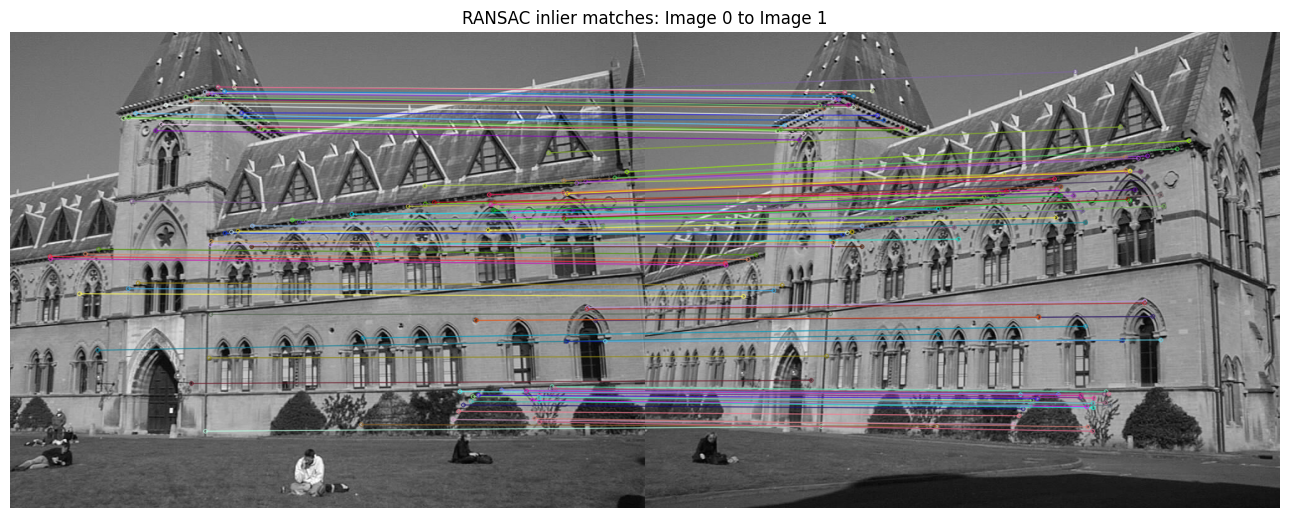

In [20]:
pts0, pts1 = match_points(matches_01, features[0], features[1])
F_cv, mask01 = cv2.findFundamentalMat(pts0, pts1, cv2.FM_RANSAC, RANSAC_THRESHOLD_PX, 0.99)
if F_cv is None or mask01 is None:
    raise RuntimeError('Fundamental matrix estimation failed.')

mask01 = mask01.ravel().astype(bool)
pts0_in = pts0[mask01]
pts1_in = pts1[mask01]
inlier_matches_01 = [m for m, keep in zip(matches_01, mask01) if keep]

F_solem = compute_fundamental_normalized(homogeneous(pts0_in), homogeneous(pts1_in))
e0 = compute_epipole(F_solem)

print('raw matches image 0-1:', len(matches_01))
print('RANSAC inliers image 0-1:', len(pts0_in))
print('Solem normalized eight-point F on inliers:\n', F_solem)
print('epipole in image 0:', e0)

show_matches(imgs[0], imgs[1], features[0], features[1], inlier_matches_01, 'RANSAC inlier matches: Image 0 to Image 1')

In [ ]:
def simple_calibration(shape: tuple[int, int]) -> np.ndarray:
    h, w = shape
    f = 1.2 * max(w, h)
    return np.array([[f, 0, w / 2], [0, f, h / 2], [0, 0, 1]], dtype=float)


def normalize_image_points(points: np.ndarray, K: np.ndarray) -> np.ndarray:
    x = np.linalg.inv(K) @ homogeneous(points)
    return (x[:2] / x[2]).T

# E = K'.T @ F @ K, where K and K' are the intrinsic calibration matrices of the two cameras. Assuming they are the same, we can use K for both.
K = simple_calibration(imgs[0].shape)
E = K.T @ F_cv @ K
_, R, t, pose_mask = cv2.recoverPose(E, pts0_in, pts1_in, K)
pose_mask = pose_mask.ravel() > 0

if pose_mask.sum() >= 8:
    pts0_pose = pts0_in[pose_mask]
    pts1_pose = pts1_in[pose_mask]
    inlier_matches_01_pose = [m for m, keep in zip(inlier_matches_01, pose_mask) if keep]
else:
    pts0_pose = pts0_in
    pts1_pose = pts1_in
    inlier_matches_01_pose = inlier_matches_01

P1 = np.hstack([np.eye(3), np.zeros((3, 1))])
P2 = np.hstack([R, t])

x0_norm = normalize_image_points(pts0_pose, K)
x1_norm = normalize_image_points(pts1_pose, K)
X = triangulate_points(x0_norm, x1_norm, P1, P2)

finite = np.all(np.isfinite(X), axis=1)
depth1 = X[:, 2]
depth2 = (R @ X[:, :3].T + t).T[:, 2]
in_front = finite & (depth1 > 0) & (depth2 > 0)
if in_front.sum() >= 8:
    X = X[in_front]
    pts0_pose = pts0_pose[in_front]
    pts1_pose = pts1_pose[in_front]
    inlier_matches_01_pose = [m for m, keep in zip(inlier_matches_01_pose, in_front) if keep]

print('approximate calibration K:\n', K)
print('pose inliers image 0-1:', len(pts0_pose))
print('triangulated 3D points:', X.shape[0])
print('P1:\n', P1)
print('P2:\n', P2)

approximate calibration K:
 [[1.2288e+03 0.0000e+00 5.1200e+02]
 [0.0000e+00 1.2288e+03 3.8400e+02]
 [0.0000e+00 0.0000e+00 1.0000e+00]]
pose inliers image 0-1: 244
triangulated 3D points: 244
P1:
 [[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]]
P2:
 [[ 0.96943281  0.03900472  0.24223678 -0.96666236]
 [-0.03286899  0.99902949 -0.02932084  0.0480387 ]
 [-0.24314534  0.02046251  0.96977401 -0.25150779]]


### Add image 2 by resection

Image 2 is matched back to image 0. If a keypoint in image 0 already has a triangulated 3D point, its match in image 2 gives a 2D-3D pair. DLT resection estimates P3 from those pairs.

RANSAC inliers image 0-2: 418
2D-3D correspondences for image 2: 93


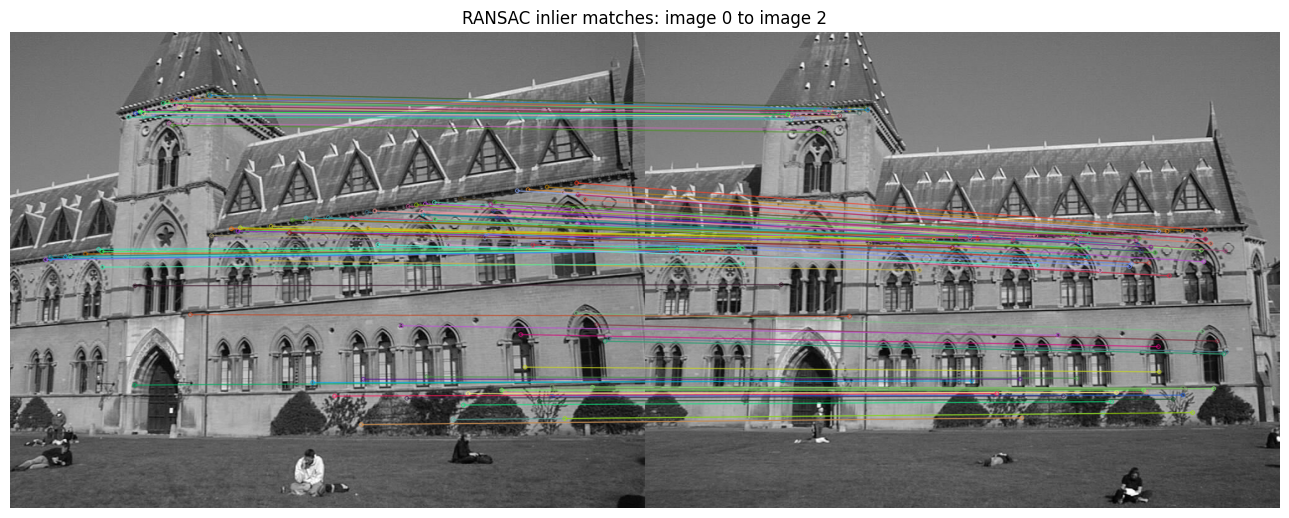

In [8]:
pts0_02, pts2_all = match_points(matches_02, features[0], features[2])
F02, mask02 = cv2.findFundamentalMat(pts0_02, pts2_all, cv2.FM_RANSAC, RANSAC_THRESHOLD_PX, 0.99)
mask02 = np.ones(len(matches_02), dtype=bool) if mask02 is None else mask02.ravel().astype(bool)
inlier_matches_02 = [m for m, keep in zip(matches_02, mask02) if keep]

triangulated_by_kp0 = {m.queryIdx: i for i, m in enumerate(inlier_matches_01_pose)}
X3_points = []
x3_points = []
for m in inlier_matches_02:
    X_index = triangulated_by_kp0.get(m.queryIdx)
    if X_index is None:
        continue
    X3_points.append(X[X_index])
    x3_points.append(features[2].keypoints[m.trainIdx].pt)

X3 = np.asarray(X3_points, dtype=float)
x3 = np.asarray(x3_points, dtype=float)

print('RANSAC inliers image 0-2:', len(inlier_matches_02))
print('2D-3D correspondences for image 2:', len(x3))
if len(x3) < 6:
    raise RuntimeError('Not enough shared 2D-3D correspondences for image 2 resection.')

show_matches(imgs[0], imgs[2], features[0], features[2], inlier_matches_02, 'RANSAC inlier matches: image 0 to image 2')

In [22]:
def ransac_camera_resection(x_points, X_points, sample_size=8, threshold_px=8.0, max_iter=1200):
    if len(x_points) < 6:
        raise ValueError('At least 6 correspondences are required for camera resection.')

    rng = np.random.default_rng(RANDOM_SEED)
    sample_size = min(sample_size, len(x_points))
    best_inliers = np.zeros(len(x_points), dtype=bool)
    x_h_all = homogeneous(x_points)
    X_h_all = X_points.T

    for _ in range(max_iter):
        sample = rng.choice(len(x_points), sample_size, replace=False)
        try:
            P_candidate = compute_camera_resection(x_h_all[:, sample], X_h_all[:, sample])
            errors = reprojection_errors(P_candidate, X_h_all, x_points)
        except np.linalg.LinAlgError:
            continue
        if not np.all(np.isfinite(errors)):
            continue
        inliers = errors < threshold_px
        if inliers.sum() > best_inliers.sum():
            best_inliers = inliers

    if best_inliers.sum() < 6:
        raise RuntimeError('Resection RANSAC failed to find enough inliers.')

    P = compute_camera_resection(x_h_all[:, best_inliers], X_h_all[:, best_inliers])
    errors = reprojection_errors(P, X_h_all, x_points)
    refined = errors < threshold_px
    if refined.sum() >= 6:
        P = compute_camera_resection(x_h_all[:, refined], X_h_all[:, refined])
        best_inliers = refined
    return P, best_inliers


P3, inliers3 = ransac_camera_resection(x3, X3)
X3_in = X3[inliers3]
x3_in = x3[inliers3]
projected3 = project(P3, X3_in.T)
errors3 = reprojection_errors(P3, X3_in.T, x3_in)

print('P3 from resection:\n', P3)
print('resection inliers:', int(inliers3.sum()))
print('mean reprojection error:', float(errors3.mean()))
print('median reprojection error:', float(np.median(errors3)))
print('90th percentile reprojection error:', float(np.percentile(errors3, 90)))

P3 from resection:
 [[-4.09993384e-01  4.95335678e-02 -2.89581755e-02 -6.58637103e-01]
 [ 1.73025585e-02 -4.35716412e-01 -2.71244800e-02 -4.51581369e-01]
 [ 6.62928477e-05  6.00500272e-05 -1.45053111e-04 -8.78624630e-04]]
resection inliers: 93
mean reprojection error: 0.9123896128001385
median reprojection error: 0.752024250578671
90th percentile reprojection error: 1.6816544318936029


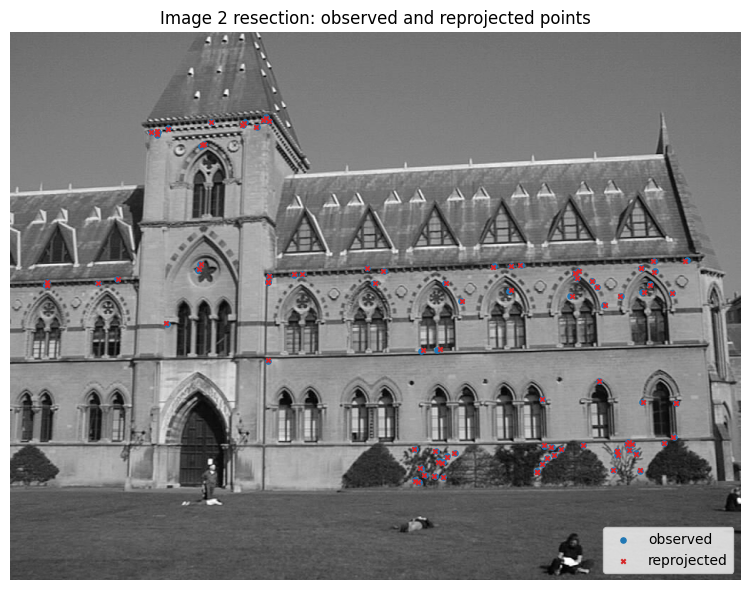

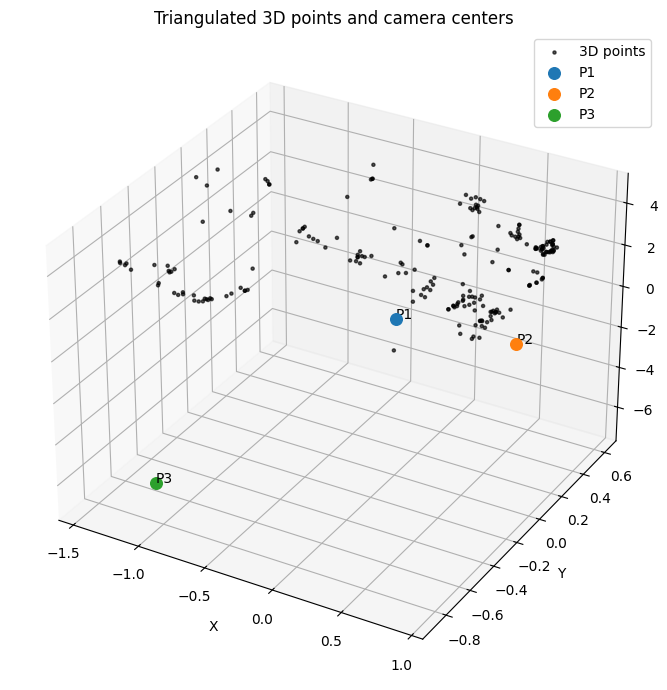

In [23]:
plt.figure(figsize=(8, 6))
plt.imshow(imgs[2], cmap='gray')
plt.scatter(x3_in[:, 0], x3_in[:, 1], s=14, c='tab:blue', label='observed')
plt.scatter(projected3[:, 0], projected3[:, 1], s=10, c='tab:red', marker='x', label='reprojected')
plt.title('Image 2 resection: observed and reprojected points')
plt.legend(loc='lower right')
plt.axis('off')
plt.tight_layout()
plt.show()

centers = {'P1': camera_center(P1), 'P2': camera_center(P2), 'P3': camera_center(P3)}
pts = X[:, :3]
pts = pts[np.all(np.isfinite(pts), axis=1)]
lo, hi = np.percentile(pts, [2, 98], axis=0)
pts_plot = pts[np.all((pts >= lo) & (pts <= hi), axis=1)]

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(pts_plot[:, 0], pts_plot[:, 1], pts_plot[:, 2], s=5, c='black', alpha=0.65, label='3D points')
for name, c in centers.items():
    ax.scatter(c[0], c[1], c[2], s=70, label=name)
    ax.text(c[0], c[1], c[2], name)
ax.set_title('Triangulated 3D points and camera centers')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.legend()
plt.tight_layout()
plt.show()

## Part (b): SSD stereo

The first two images are rectified so matching points are close to the same scanline. Each pixel then searches over disparities and keeps the disparity with the smallest SSD patch cost.

Small patches keep sharper boundaries but are noisy. Large patches reduce noise but blur across depth edges.

rectified: True


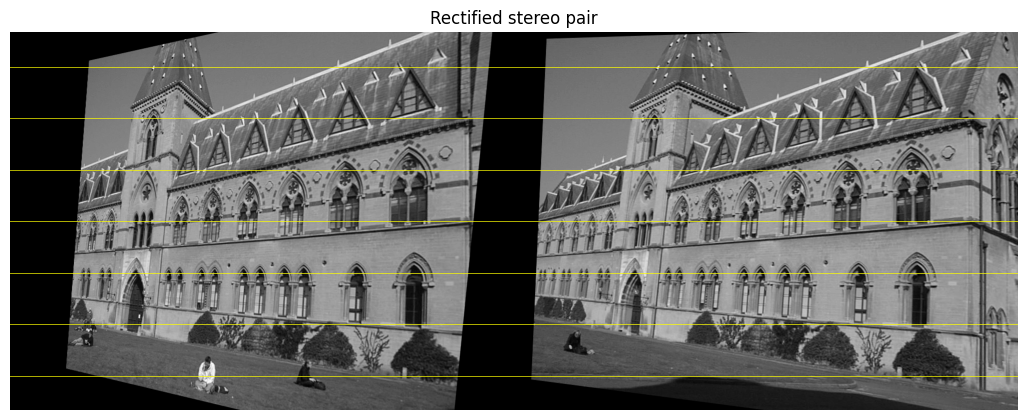

In [11]:
def rectify_pair(image_a, image_b, pts_a, pts_b, F):
    size = (image_a.shape[1], image_a.shape[0])
    ok, H1, H2 = cv2.stereoRectifyUncalibrated(pts_a, pts_b, F, size)
    if not ok:
        print('Rectification failed; using original pair.')
        return image_a, image_b, False
    rect_a = cv2.warpPerspective(image_a, H1, size)
    rect_b = cv2.warpPerspective(image_b, H2, size)
    return rect_a, rect_b, True


def shift_with_mask(image: np.ndarray, disparity: int):
    shifted = np.zeros_like(image, dtype=np.float32)
    mask = np.zeros_like(image, dtype=np.float32)
    if disparity > 0:
        shifted[:, disparity:] = image[:, :-disparity]
        mask[:, disparity:] = 1
    elif disparity < 0:
        shifted[:, :disparity] = image[:, -disparity:]
        mask[:, :disparity] = 1
    else:
        shifted[:, :] = image
        mask[:, :] = 1
    return shifted, mask


def ssd_disparity(left: np.ndarray, right: np.ndarray, patch_size: int, max_disparity: int = MAX_DISPARITY):
    left_f = left.astype(np.float32) / 255.0
    right_f = right.astype(np.float32) / 255.0
    best_cost = np.full(left_f.shape, np.inf, dtype=np.float32)
    best_disp = np.zeros(left_f.shape, dtype=np.float32)
    valid_best = np.zeros(left_f.shape, dtype=bool)
    area = patch_size * patch_size

    for d in range(-max_disparity, max_disparity + 1):
        shifted, valid = shift_with_mask(right_f, d)
        sum_left2 = cv2.boxFilter((left_f ** 2) * valid, -1, (patch_size, patch_size), normalize=False, borderType=cv2.BORDER_CONSTANT)
        sum_right2 = cv2.boxFilter((shifted ** 2) * valid, -1, (patch_size, patch_size), normalize=False, borderType=cv2.BORDER_CONSTANT)
        sum_cross = cv2.boxFilter(left_f * shifted * valid, -1, (patch_size, patch_size), normalize=False, borderType=cv2.BORDER_CONSTANT)
        count = cv2.boxFilter(valid, -1, (patch_size, patch_size), normalize=False, borderType=cv2.BORDER_CONSTANT)
        cost = (sum_left2 + sum_right2 - 2 * sum_cross) / np.maximum(count, 1)
        full_window = count > 0.9 * area
        update = full_window & (cost < best_cost)
        best_cost[update] = cost[update]
        best_disp[update] = float(d)
        valid_best |= update

    best_disp[~valid_best] = 0
    return best_disp, valid_best


def normalize_for_display(values: np.ndarray, valid: np.ndarray | None = None):
    valid = np.isfinite(values) if valid is None else valid
    vals = values[valid]
    if vals.size == 0:
        return np.zeros_like(values, dtype=np.float32)
    lo, hi = np.percentile(vals, [2, 98])
    if hi <= lo:
        hi = lo + 1
    return np.clip((values - lo) / (hi - lo), 0, 1).astype(np.float32)


rect_left, rect_right, rectified = rectify_pair(imgs[0], imgs[1], pts0_in, pts1_in, F_cv)
print('rectified:', rectified)

pair = np.hstack([rect_left, rect_right])
plt.figure(figsize=(13, 5))
plt.imshow(pair, cmap='gray')
for y in np.linspace(70, rect_left.shape[0] - 70, 7):
    plt.axhline(y, color='yellow', linewidth=0.7, alpha=0.7)
plt.title('Rectified stereo pair')
plt.axis('off')
plt.show()

patch 7: valid pixels=775716, median disparity=5.00, std=32.22
patch 11: valid pixels=772156, median disparity=5.00, std=31.74
patch 19: valid pixels=758012, median disparity=6.00, std=31.37


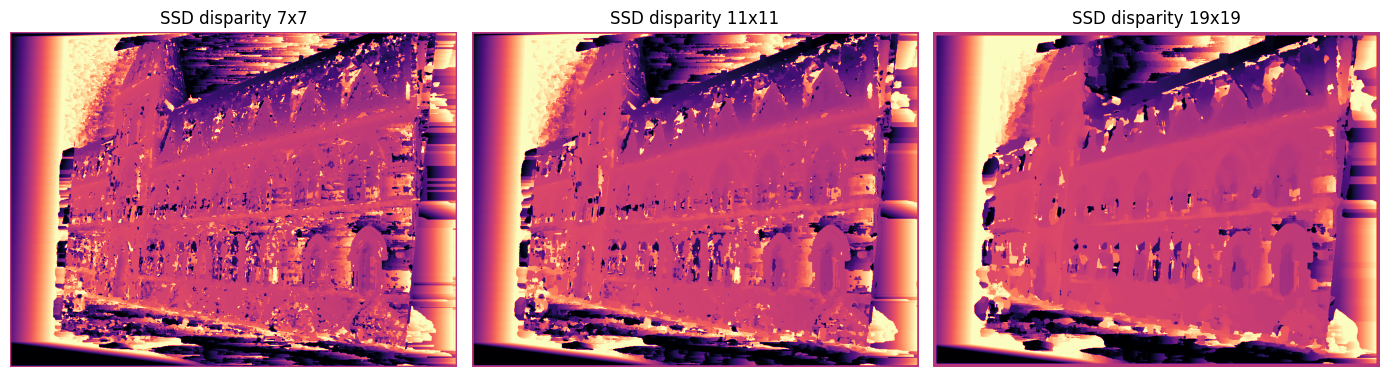

In [ ]:
disparities = {}
for patch in PATCH_SIZES:
    disp, valid = ssd_disparity(rect_left, rect_right, patch_size=patch, max_disparity=MAX_DISPARITY)
    disparities[patch] = (disp, valid)
    print(
        f'patch {patch}: valid pixels={valid.sum()}, '
        f'median disparity={np.median(disp[valid]):.2f}, '
        f'std={np.std(disp[valid]):.2f}'
    )

fig, axes = plt.subplots(1, len(PATCH_SIZES), figsize=(14, 4))
for ax, patch in zip(axes, PATCH_SIZES):
    disp, valid = disparities[patch]
    ax.imshow(normalize_for_display(disp, valid), cmap='magma')
    ax.set_title(f'SSD disparity {patch}x{patch}')
    ax.axis('off')
plt.tight_layout()
plt.show()

# 

## Part (c): ROF smoothing

ROF smoothing is applied to normalized disparity maps. It removes isolated noisy pixels while keeping stronger edges better than ordinary averaging.

patch 7: ROF iterations=61, disparity misfit RMS=7.6206
patch 11: ROF iterations=59, disparity misfit RMS=5.5396
patch 19: ROF iterations=52, disparity misfit RMS=3.8006


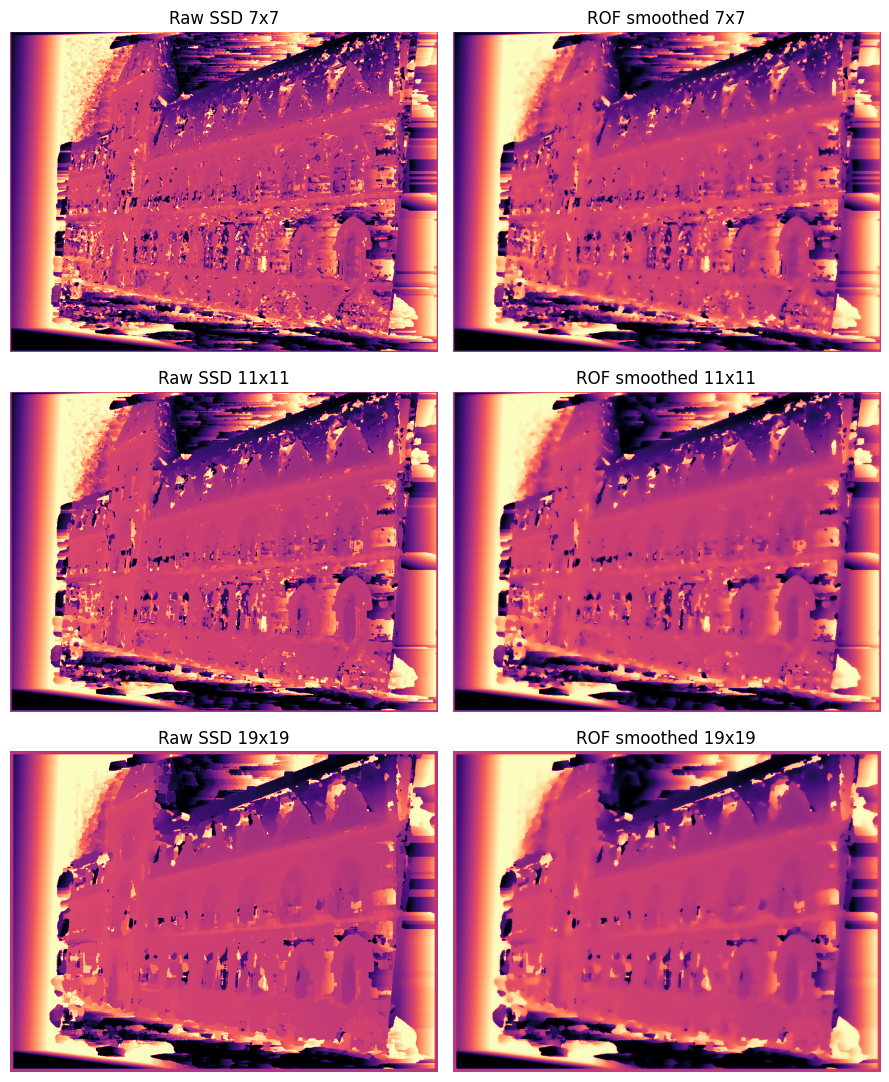

In [ ]:
# tau = step size for dual variable update
# tv_weight = lambda in the ROF paper, controls the strength of the TV regularization
# tolerance = convergence threshold for the relative change in U 
def denoise_rof(im, U_init=None, tolerance=0.02, tau=0.125, tv_weight=18.0, max_iter=250):
    im = im.astype(np.float32)
    U = im.copy() if U_init is None else U_init.astype(np.float32).copy()
    Px = np.zeros_like(im)
    Py = np.zeros_like(im)
    error = np.inf
    iteration = 0

    while error > tolerance and iteration < max_iter:
        Uold = U.copy()
        GradUx = np.roll(U, -1, axis=1) - U
        GradUy = np.roll(U, -1, axis=0) - U

        Px_new = Px + (tau / tv_weight) * GradUx
        Py_new = Py + (tau / tv_weight) * GradUy

        norm_new = np.maximum(1, np.sqrt(Px_new**2 + Py_new**2))
        Px = Px_new / norm_new
        Py = Py_new / norm_new

        DivP = (Px - np.roll(Px, 1, axis=1)) + (Py - np.roll(Py, 1, axis=0))
        U = im + tv_weight * DivP
        
        error = np.linalg.norm(U - Uold) / np.sqrt(im.size)
        iteration += 1

    texture = im - U
    misfit_rms = np.linalg.norm(texture) / np.sqrt(im.size)
    return U, texture, iteration, misfit_rms


rof_maps = {}
rof_stats = {}

for patch in PATCH_SIZES:
    disp, valid = disparities[patch]

    # Work on raw disparity values, not display-normalised values
    disp_for_rof = disp.astype(np.float32).copy()

    # Fill invalid pixels before ROF so undefined regions do not dominate the update
    if np.any(valid):
        fill_value = np.median(disp_for_rof[valid])
    else:
        fill_value = 0.0

    disp_for_rof[~valid] = fill_value

    smoothed, texture, iterations, misfit_rms = denoise_rof(
        disp_for_rof,
        disp_for_rof,
        tv_weight=18.0,
        tolerance=0.02
    )

    # Store raw smoothed disparity map and validity mask
    rof_maps[patch] = (smoothed, valid)
    rof_stats[patch] = {
        "iterations": iterations,
        "disparity_misfit_rms": misfit_rms
    }

    print(
        f"patch {patch}: ROF iterations={iterations}, "
        f"disparity misfit RMS={misfit_rms:.4f}"
    )

fig, axes = plt.subplots(len(PATCH_SIZES), 2, figsize=(9, 11))

for row, patch in enumerate(PATCH_SIZES):
    disp, valid = disparities[patch]
    smoothed, _ = rof_maps[patch]

    # Normalisation only happens here, for visualisation
    raw_display = normalize_for_display(disp, valid)
    smoothed_display = normalize_for_display(smoothed, valid)

    axes[row, 0].imshow(raw_display, cmap="magma")
    axes[row, 0].set_title(f"Raw SSD {patch}x{patch}")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(smoothed_display, cmap="magma")
    axes[row, 1].set_title(f"ROF smoothed {patch}x{patch}")
    axes[row, 1].axis("off")

plt.tight_layout()
plt.show()


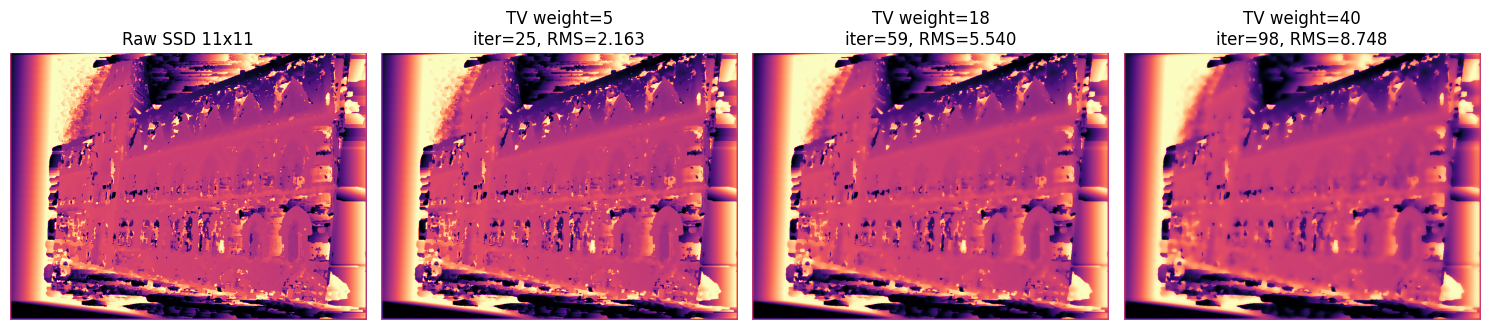

In [61]:
patch = 11
disp, valid = disparities[patch]

disp_for_rof = disp.astype(np.float32).copy()

if np.any(valid):
    fill_value = np.median(disp_for_rof[valid])
else:
    fill_value = 0.0

disp_for_rof[~valid] = fill_value

tv_weights = [5.0, 18.0, 40.0]

fig, axes = plt.subplots(1, len(tv_weights) + 1, figsize=(15, 4))

axes[0].imshow(normalize_for_display(disp, valid), cmap="magma")
axes[0].set_title("Raw SSD 11x11")
axes[0].axis("off")

for i, weight in enumerate(tv_weights, start=1):
    smoothed, texture, iterations, misfit_rms = denoise_rof(
        disp_for_rof,
        disp_for_rof,
        tv_weight=weight,
        tolerance=0.02
    )

    axes[i].imshow(normalize_for_display(smoothed, valid), cmap="magma")
    axes[i].set_title(
        f"TV weight={weight:g}\n"
        f"iter={iterations}, RMS={misfit_rms:.3f}"
    )
    axes[i].axis("off")

plt.tight_layout()
plt.show()

### Results and conclusions

The first part (a) estimates a sparse multi-view reconstruction. The first two images give camera matrices and triangulated 3D points. Image 2 is added by resection from shared 2D-3D correspondences. The printed reprojection errors check whether `P3` maps the 3D points back near the observed image points.

Then part (b) computes SSD stereo disparity after rectification. The values are relative disparities, not metric depths.

Part (c) shows the expected patch-size tradeoff. Small SSD patches preserve edges but contain more noise. Larger patches are smoother but blur boundaries. ROF smoothing removes much of the speckle while keeping stronger edges visible.

Main limitations:

- The approximate calibration makes the 3D scale arbitrary.
- Uncalibrated rectification can shear the images.
- SSD assumes similar brightness and locally fronto-parallel patches.
- A larger reconstruction would use more images, true calibration, and bundle adjustment.